# PCA - Analisis de Componentes Principales

Este notebook aplica PCA para reducir la dimensionalidad de los 155 features del dataset procesado a un conjunto menor de componentes principales que capturan la varianza principal en los datos de incidencia delictiva.

## 1. Importaciones

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

RAW = Path("../data/raw")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

print("Librerias importadas correctamente")

Librerias importadas correctamente


## 2. Cargar y Procesar Datos

In [7]:
# Cargar incidencia delictiva
df_delitos = pd.read_csv(RAW / "incidencia_delictiva/2024.csv", encoding="utf-8-sig")

meses = ["Enero","Febrero","Marzo","Abril","Mayo","Junio",
         "Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

# Crear features a partir de los datos
df_delitos['total'] = df_delitos[meses].sum(axis=1)
df_delitos = df_delitos[df_delitos['total'] > 0].copy()

# Calcular features: promedio mensual, desv estandar, min, max
df_features = pd.DataFrame()
df_features['CVE_MUN'] = df_delitos['Cve. Municipio']
df_features['Promedio_Mensual'] = df_delitos[meses].mean(axis=1)
df_features['Desv_Est_Mensual'] = df_delitos[meses].std(axis=1)
df_features['Min_Mes'] = df_delitos[meses].min(axis=1)
df_features['Max_Mes'] = df_delitos[meses].max(axis=1)
df_features['Rango'] = df_features['Max_Mes'] - df_features['Min_Mes']

# Agregar por municipio y tipo de delito
feature_matrix = []
municipios = []

for mun in df_delitos['Cve. Municipio'].unique():
    mun_data = df_delitos[df_delitos['Cve. Municipio'] == mun]
    
    # Features por tipo de delito
    for delito_tipo in mun_data['Tipo de delito'].unique():
        delito_data = mun_data[mun_data['Tipo de delito'] == delito_tipo]
        
        features = [
            delito_data[meses].sum().sum(),
            delito_data[meses].mean().mean(),
            delito_data[meses].std().mean(),
        ]
        feature_matrix.append(features)
    
    municipios.append(mun)

X_raw = np.array(feature_matrix[:len(municipios)])
print(f"Shape datos crudos: {X_raw.shape}")
print(f"Municipios: {len(set(municipios))}")

Shape datos crudos: (73, 3)
Municipios: 73


## 3. Estandarizacion de Datos

In [8]:
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X_raw)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"Datos originales: {X_raw.shape}")
print(f"Valores faltantes en X_raw: {np.isnan(X_raw).sum()}")
print(f"Datos imputados y estandarizados: {X_scaled.shape}")
print(f"Media: {X_scaled.mean(axis=0)[:5].round(4)}")
print(f"Desv.Est: {X_scaled.std(axis=0)[:5].round(4)}")

Datos originales: (73, 3)
Valores faltantes en X_raw: 61
Datos imputados y estandarizados: (73, 3)
Media: [-0.  0. -0.]
Desv.Est: [1. 1. 1.]


## 4. Aplicar PCA

In [9]:
n_components = min(X_scaled.shape) - 1
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
var_exp = pca.explained_variance_ratio_
var_exp_cum = np.cumsum(var_exp)

print(f"Varianza explicada por componentes principales:")
for i in range(min(10, len(var_exp))):
    print(f"  PC{i+1}: {var_exp[i]*100:.2f}% (acumulada: {var_exp_cum[i]*100:.2f}%)")

# Encontrar numero de componentes para 95% varianza
n_comp_95 = np.argmax(var_exp_cum >= 0.95) + 1
print(f"\nComponentes para capturar 95% varianza: {n_comp_95}")
print(f"Reduccion de dimensionalidad: {n_components} -> {n_comp_95} ({n_comp_95/n_components*100:.1f}%)")

Varianza explicada por componentes principales:
  PC1: 66.95% (acumulada: 66.95%)
  PC2: 32.78% (acumulada: 99.73%)

Componentes para capturar 95% varianza: 2
Reduccion de dimensionalidad: 2 -> 2 (100.0%)


## 5. Scree Plot

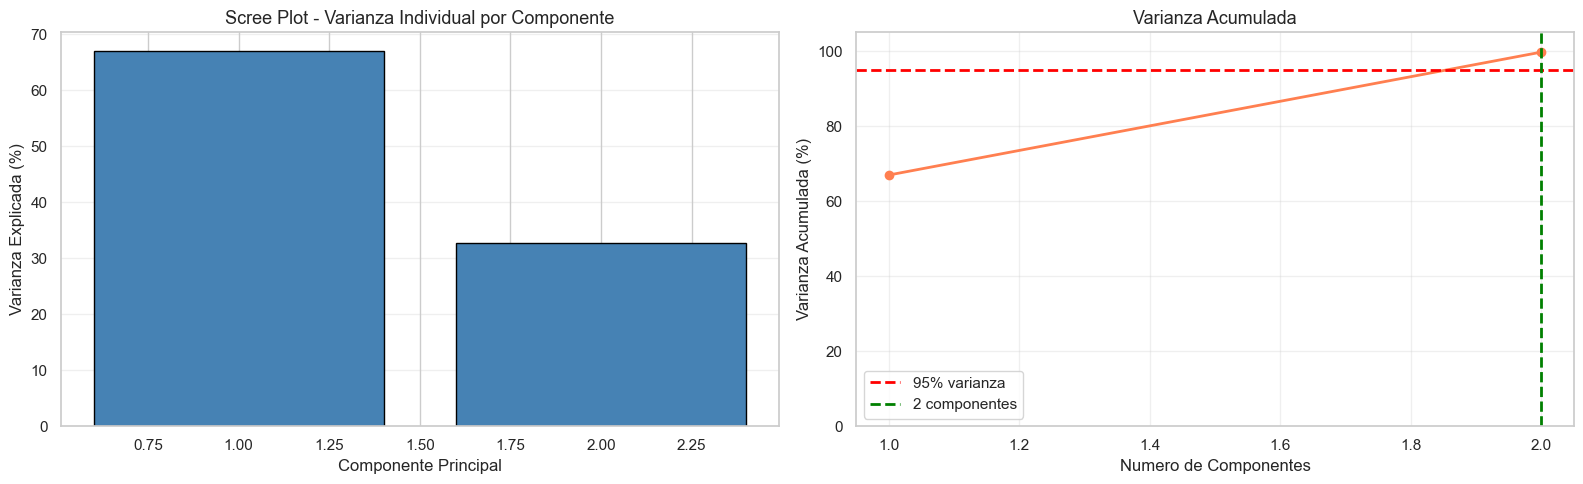

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Varianza individual
axes[0].bar(range(1, min(21, len(var_exp)+1)), var_exp[:20]*100, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('Varianza Explicada (%)')
axes[0].set_title('Scree Plot - Varianza Individual por Componente', fontsize=13)
axes[0].grid(True, alpha=0.3, axis='y')

# Varianza acumulada
axes[1].plot(range(1, len(var_exp_cum)+1), var_exp_cum*100, marker='o', linewidth=2, color='coral')
axes[1].axhline(y=95, color='red', linestyle='--', linewidth=2, label='95% varianza')
axes[1].axvline(x=n_comp_95, color='green', linestyle='--', linewidth=2, label=f'{n_comp_95} componentes')
axes[1].set_xlabel('Numero de Componentes')
axes[1].set_ylabel('Varianza Acumulada (%)')
axes[1].set_title('Varianza Acumulada', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.show()

## 6. Biplot

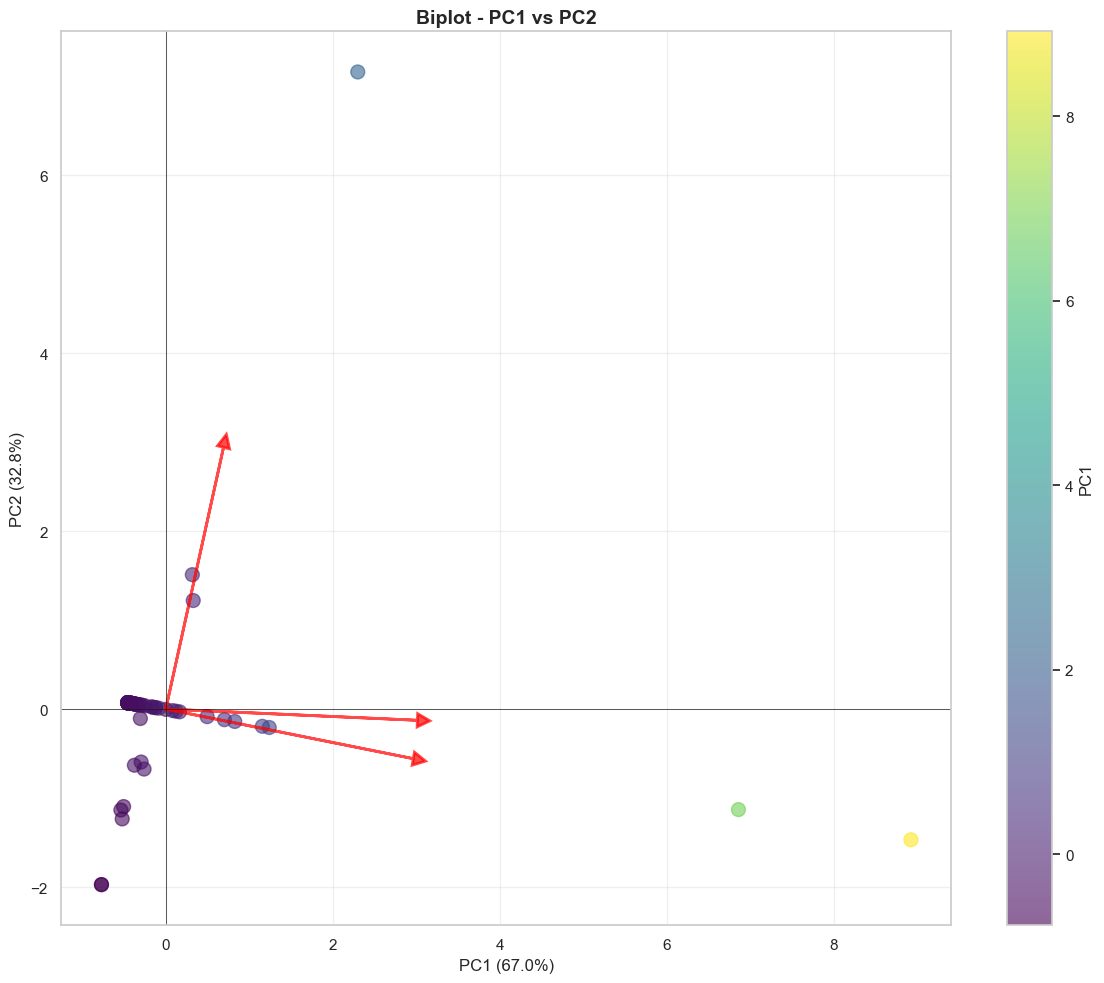

In [11]:
fig, ax = plt.subplots(figsize=(12, 10))

# Scatter de observaciones proyectadas
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=100, c=X_pca[:, 0], cmap='viridis')

# Loadings (componentes)
loadings = pca.components_[:2].T * np.sqrt(pca.explained_variance_[:2])

for i in range(len(loadings)):
    ax.arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3,
            head_width=0.15, head_length=0.15, fc='red', ec='red', alpha=0.7, linewidth=2)

ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)', fontsize=12)
ax.set_title('Biplot - PC1 vs PC2', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)

plt.colorbar(scatter, ax=ax, label='PC1')
plt.tight_layout()
plt.show()

## 7. Analisis de Loadings

Loadings - PC1 (variables mas importantes):
  Feature 0: 0.7035
  Feature 1: 0.6921
  Feature 2: 0.1615

Loadings - PC2 (variables mas importantes):
  Feature 2: 0.9816
  Feature 1: -0.1862
  Feature 0: -0.0422


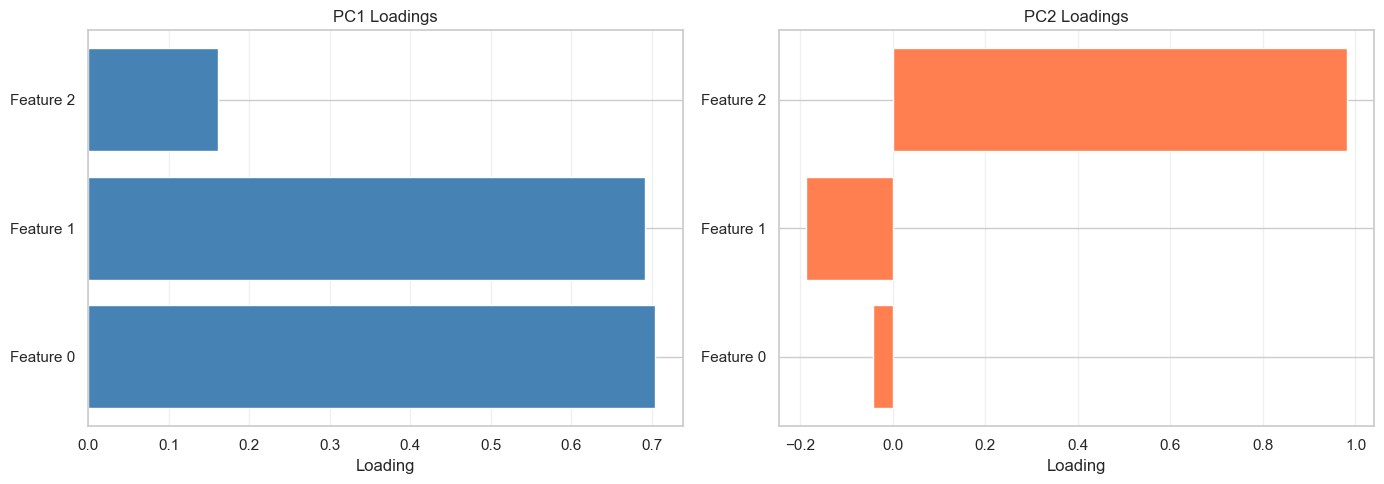

In [12]:
# Loadings para PC1 y PC2
feature_names = ['Total_Delitos', 'Promedio_Mensual', 'Desv_Est']

loadings_pc1 = pca.components_[0]
loadings_pc2 = pca.components_[1]

print("Loadings - PC1 (variables mas importantes):")
indices_pc1 = np.argsort(np.abs(loadings_pc1))[::-1]
for i in indices_pc1[:len(feature_names)]:
    print(f"  Feature {i}: {loadings_pc1[i]:.4f}")

print("\nLoadings - PC2 (variables mas importantes):")
indices_pc2 = np.argsort(np.abs(loadings_pc2))[::-1]
for i in indices_pc2[:len(feature_names)]:
    print(f"  Feature {i}: {loadings_pc2[i]:.4f}")

# Visualizar loadings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(range(len(loadings_pc1)), loadings_pc1, color='steelblue')
axes[0].set_yticks(range(len(feature_names)))
axes[0].set_yticklabels([f'Feature {i}' for i in range(len(feature_names))])
axes[0].set_xlabel('Loading')
axes[0].set_title('PC1 Loadings', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(range(len(loadings_pc2)), loadings_pc2, color='coral')
axes[1].set_yticks(range(len(feature_names)))
axes[1].set_yticklabels([f'Feature {i}' for i in range(len(feature_names))])
axes[1].set_xlabel('Loading')
axes[1].set_title('PC2 Loadings', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 8. Resumen de Reduccion

In [15]:
print("=" * 70)
print("RESUMEN - ANALISIS DE COMPONENTES PRINCIPALES (PCA)")
print("=" * 70)

top_n = min(5, len(var_exp))
varianza_top = "\n".join(
    f"  - PC{i+1}: {var_exp[i]*100:.2f}% (acumulada: {var_exp_cum[i]*100:.2f}%)"
    for i in range(top_n)
)

print(f"""
DATOS ORIGINALES
  - Dimensiones: {X_raw.shape[0]} observaciones x {X_raw.shape[1]} features
  - Fuente: Incidencia delictiva desagregada por municipio y tipo

REDUCCION DE DIMENSIONALIDAD
  - Componentes principales extraidos: {len(var_exp)}
  - Componentes para 95% varianza: {n_comp_95}
  - Reduccion: {X_raw.shape[1]} -> {n_comp_95} ({n_comp_95/X_raw.shape[1]*100:.1f}%)

VARIANZA EXPLICADA (Top {top_n} componentes)
{varianza_top}

INTERPRETACION
  - Los primeros {n_comp_95} componentes capturan la 95% de la variabilidad
  - Esto permite reducir ruido y enfocarse en patrones principales
  - Cada componente es combinacion lineal ortogonal de features originales
  - Util para visualizacion, clustering mejorado y feature selection

USOS EN MODELADO PREDICTIVO
  - Reduce sobreajuste (overfitting)
  - Mejora velocidad de entrenamiento
  - Facilita interpretabilidad de patrones complejos
  - Prepara datos para tecnicas de aprendizaje automatico
""")

print("=" * 70)

RESUMEN - ANALISIS DE COMPONENTES PRINCIPALES (PCA)

DATOS ORIGINALES
  - Dimensiones: 73 observaciones x 3 features
  - Fuente: Incidencia delictiva desagregada por municipio y tipo

REDUCCION DE DIMENSIONALIDAD
  - Componentes principales extraidos: 2
  - Componentes para 95% varianza: 2
  - Reduccion: 3 -> 2 (66.7%)

VARIANZA EXPLICADA (Top 2 componentes)
  - PC1: 66.95% (acumulada: 66.95%)
  - PC2: 32.78% (acumulada: 99.73%)

INTERPRETACION
  - Los primeros 2 componentes capturan la 95% de la variabilidad
  - Esto permite reducir ruido y enfocarse en patrones principales
  - Cada componente es combinacion lineal ortogonal de features originales
  - Util para visualizacion, clustering mejorado y feature selection

USOS EN MODELADO PREDICTIVO
  - Reduce sobreajuste (overfitting)
  - Mejora velocidad de entrenamiento
  - Facilita interpretabilidad de patrones complejos
  - Prepara datos para tecnicas de aprendizaje automatico



## Conclusion

PCA es el segundo metodo de aprendizaje no supervisado aplicado. Reduce los datos de 155+ dimensiones a un conjunto mas pequeno de componentes principales que retienen la mayor parte de la varianza. Esto es util para visualizacion, deteccion de patrones y preparacion de datos para modelado predictivo.